In [419]:
import pandas as pd

In [420]:
df = pd.read_csv('delivery_processed1.csv')
df.tail()

,pickup_pincode,delivery_pincode,pickup_prefix,delivery_prefix,product_category,weather,weight_kg,delivery_days
99995,815866,491711,81,49,STANDARD,SUNNY,0.46,2
99996,429718,613765,42,61,DELICATE,CLOUDY,0.33,4
99997,952059,532935,95,53,DELICATE,RAINY,3.55,6
99998,115928,233314,11,23,STANDARD,RAINY,20.68,4
99999,485785,439519,48,43,STANDARD,SUNNY,13.41,2


In [421]:
df['weight_bucket'] = pd.cut(df['weight_kg'], 
                              bins=[0, 1, 5, 10, 20, 50, float('inf')],
                              labels=['tiny', 'light', 'medium', 'heavy', 'very_heavy', 'bulk'])

X = df[['pickup_prefix', 'delivery_prefix', 
        'product_category', 'weather', 'weight_bucket']]

In [422]:
y = df['delivery_days']

In [423]:
X.head()

,pickup_prefix,delivery_prefix,product_category,weather,weight_bucket
0,68,25,STANDARD,SUNNY,light
1,36,13,DELICATE,CLOUDY,tiny
2,74,33,STANDARD,CLOUDY,light
3,78,78,STANDARD,SUNNY,medium
4,67,17,DELICATE,STORMY,tiny


In [424]:
y.head()

0    5
1    4
2    4
3    1
4    7
Name: delivery_days, dtype: int64

In [425]:
#train test split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=32)

In [426]:
X_train.head()

,pickup_prefix,delivery_prefix,product_category,weather,weight_bucket
71932,42,17,STANDARD,SUNNY,medium
15908,44,18,STANDARD,SUNNY,very_heavy
29592,53,14,STANDARD,SUNNY,heavy
71634,36,25,STANDARD,CLOUDY,tiny
9517,64,85,STANDARD,SUNNY,tiny


In [427]:
y_train.tail()

24828    4
20414    2
60284    3
75062    1
10967    5
Name: delivery_days, dtype: int64

In [428]:
X_train['weather'].unique()

<StringArray>
['SUNNY', 'CLOUDY', 'STORMY', 'RAINY']
Length: 4, dtype: str

In [429]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [430]:
ct = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['weather', 'weight_bucket']),
   ('le',  OneHotEncoder(drop='if_binary', sparse_output=False), ['product_category'])
    
], remainder='passthrough')

In [431]:
X_train_enc = ct.fit_transform(X_train)
X_test_enc  = ct.transform(X_test)

In [432]:
X_train_enc.shape

(71999, 10)

In [433]:
X_train_enc

array([[ 0.,  0.,  1., ...,  1., 42., 17.],
       [ 0.,  0.,  1., ...,  1., 44., 18.],
       [ 0.,  0.,  1., ...,  1., 53., 14.],
       ...,
       [ 0.,  0.,  1., ...,  1., 52., 20.],
       [ 0.,  0.,  1., ...,  1., 80., 41.],
       [ 1.,  0.,  0., ...,  1., 16., 85.]], shape=(71999, 10))

In [434]:
feature_names = ct.get_feature_names_out()
X_train_enc = pd.DataFrame(X_train_enc, columns=feature_names)
X_test_enc  = pd.DataFrame(X_test_enc,  columns=feature_names)

In [435]:
import xgboost as xgb

In [436]:
model = xgb.XGBClassifier(objective='multi:softprob', 
                          n_estimators=600,
                          max_depth=8,
                          learning_rate=0.08,
                          subsample=0.8,
                          min_child_weight=3,
                          random_state=42)

In [437]:
y_train_enc = y_train - 1
y_test_enc  = y_test - 1

model.fit(X_train_enc, y_train_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [438]:
X_test = ct.transform(X_test)


In [439]:
y_pred = model.predict(X_test_enc)

In [440]:
from sklearn.metrics import accuracy_score, classification_report

In [441]:
accuracy_score(y_test_enc, y_pred)

0.5477661512088854

In [442]:
print(classification_report(y_test_enc, y_pred))

              precision    recall  f1-score   support

           0       0.41      0.22      0.28      1110
           1       0.58      0.48      0.52      4215
           2       0.62      0.67      0.64      6748
           3       0.60      0.65      0.62      5739
           4       0.57      0.61      0.59      4063
           5       0.45      0.45      0.45      2517
           6       0.38      0.36      0.37      1892
           7       0.33      0.36      0.34      1031
           8       0.26      0.24      0.25       516
           9       0.45      0.36      0.40       170

    accuracy                           0.55     28001
   macro avg       0.46      0.44      0.45     28001
weighted avg       0.54      0.55      0.54     28001



In [443]:
sample = X_test[0].reshape(1, -1)

proba = model.predict_proba(sample)[0]
actual_days = model.classes_ + 1

for day, prob in zip(actual_days, proba):
    print(f"Day {day}: {round(prob*100, 1)}%")

Day 1: 0.0%
Day 2: 0.20000000298023224%
Day 3: 50.70000076293945%
Day 4: 45.79999923706055%
Day 5: 3.200000047683716%
Day 6: 0.0%
Day 7: 0.0%
Day 8: 0.0%
Day 9: 0.0%
Day 10: 0.0%


In [450]:
new_data = pd.DataFrame([{
    'pickup_pincode':   999958,
    'delivery_pincode': 158664,
    'pickup_prefix':    46,
    'delivery_prefix':  81,
    'product_category': 'STANDARD',
    'weather':          'SUNNY',
    'weight_bucket':        'medium'
}])

new_encoded = ct.transform(new_data)
proba = model.predict_proba(new_encoded)[0]

for day, prob in zip(model.classes_ + 1, proba):
    print(f"Day {day}: {round(prob*100, 1)}%")

Day 1: 33.70000076293945%
Day 2: 63.900001525878906%
Day 3: 2.0999999046325684%
Day 4: 0.20000000298023224%
Day 5: 0.10000000149011612%
Day 6: 0.0%
Day 7: 0.0%
Day 8: 0.0%
Day 9: 0.0%
Day 10: 0.0%


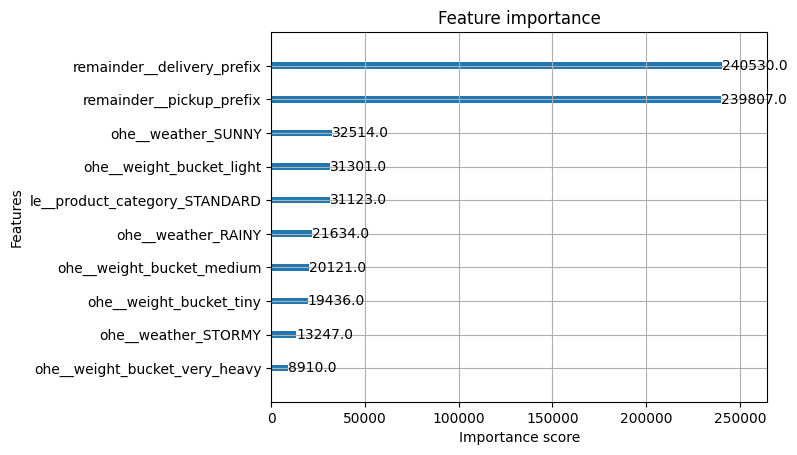

In [445]:
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10)
plt.show()